# 第7章 CartPole（DQN）：表からニューラルネットワークへ

第0〜2章で動かした、台車の上の棒を倒さないように立て続ける **CartPole** に戻ってきました。第3〜6章では、状態（または観測）と行動の組み合わせごとの値を、表に覚えさせました。FrozenLake の状態は 16 個、Taxi は 500 個と、数えられる数だったからです。CartPole の観測は、台車の位置・速度、棒の角度・角速度の4つの **連続した数**（小数）で、取りうる値を数え上げられません。このままでは、表のマスを用意できません。

この章では、まず、観測を区切って（離散化して）表に収め、第3章の Q学習で解いてみます。次に、表の代わりに **ニューラルネットワーク** で Q 値を表す **DQN**（Deep Q-Network）を、Stable-Baselines3（SB3）で動かして楽しみます。そのあと、PyTorch で書いた短い DQN のサンプルを読み、DQN を安定させる2つの工夫（**経験再生** と **ターゲットネットワーク**）を、外したときと比べます。

- **前提**: [第1章](../ch01_first_training/ch01_first_training.ipynb)（SB3 の使い方）と[第3章 FrozenLake](../ch03_frozenlake/ch03_frozenlake.ipynb)〜[第6章 Blackjack](../ch06_blackjack/ch06_blackjack.ipynb)（表形式の手法）を終えていること
- **所要の目安**: 実行は CPU で 10 分ほど（著者の環境で、Notebook 全体を上から実行して約 8 分）
- **使う装置**: CPU で十分です（この章では GPU を使いません）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、Stable-Baselines3 2.9.0、PyTorch 2.14.1）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。学習にかかる時間は、パソコンによって変わります。
> - **4-4節（TensorBoard）** の画面の説明は、第1章と同じく、公式の文書から想定したものです。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. CartPole の観測が連続した数であることと、区切って表に収めたときに何が起きるかを説明できる
2. SB3 の DQN を、RL Zoo の調整済みのハイパーパラメータで学習させ、成績・棒を立てる様子・学習曲線を見られる
3. DQN が Q 表をニューラルネットワークに置き換えたものであることと、経験再生とターゲットネットワークがサンプルのどの行に当たるかを説明できる
4. 経験再生やターゲットネットワークを外したときに何が変わるかを、測った値で説明できる

完了条件は、この Notebook を上から最後まで実行して、4節で SB3 の DQN が残した「一番よい時点のモデル」が、100 回の評価で報酬の合計の平均 475 以上になることです（Gymnasium は、CartPole-v1 を「解けた」とみなす目安を 475 としています）。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | 表で解いてみる | 連続した観測、区切った観測での Q学習の成績と、使ったステップ数 |
| 4節 | 動かして楽しむ：SB3 の DQN | 成績、棒を立てる様子、学習曲線、TensorBoard |
| 5節 | 読む(1)：Q ネットワーク | ネットワークの形と、出てくる Q 値 |
| 6節 | 読む(2)：PyTorch の DQN のサンプル | 経験再生、ターゲットネットワーク、ネットワークの重みの更新 |
| 7節 | 比べる：工夫を外す | 3通りの設定の学習曲線、成績、Q 値の大きさ |
| 8節 | 遊んでみる | 試してみる設定 |

DQN は、概要資料の[強化学習の手法の地図](../../overview/rl.md)で、「表で覚える」領域の Q学習から、「ニューラルネットワークで近似する」領域へ伸びる「表 → ネットワーク」の矢印の先にある手法です。ニューラルネットワークの計算には PyTorch を使います。PyTorch の基本は、概要資料の [PyTorch](../../overview/pytorch.md) にまとめています。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う関数を用意します。

In [1]:
import copy
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from torch import nn

torch.set_num_threads(1)  # 計算に使うスレッドを1つにする（著者が seed を変えて測ったときの条件とそろえるため）

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


# 方策 policy（観測 → 行動の番号を返す関数）で episodes 回遊ばせ、報酬の合計の平均と標準偏差を返す
def evaluate(policy, episodes=100, seed=100):
    env = gym.make("CartPole-v1")
    totals = np.zeros(episodes)
    for i in range(episodes):
        observation, info = env.reset(seed=seed if i == 0 else None)
        while True:
            observation, reward, terminated, truncated, info = env.step(policy(observation))
            totals[i] += reward
            if terminated or truncated:
                break
    return totals.mean(), totals.std()


# 方策 policy で1エピソード遊ばせ、every ステップごとの (ステップ数, 絵) の一覧を返す（絵は Gymnasium の描画）
def record_episode(policy, seed, every=5):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    observation, info = env.reset(seed=seed)
    shots = [(0, env.render())]
    steps = 0
    while True:
        observation, reward, terminated, truncated, info = env.step(policy(observation))
        steps += 1
        if steps % every == 0 or terminated or truncated:
            shots.append((steps, env.render()))
        if terminated or truncated:
            return shots

関数の説明:

- `evaluate` は、方策（観測を受け取って行動の番号を返す関数）で 100 回遊ばせ、報酬の合計の平均と標準偏差を返す関数です。表の方策、SB3 のモデル、PyTorch のネットワークを、同じ関数で評価できるように、方策を関数で受け取ります。最初の `reset` にだけ `seed=100` を渡すので、どの方策も、同じ始まり方の 100 回で比べられます
- `record_episode` は、方策で1エピソード遊ばせ、5 ステップごとの絵を集める関数です。絵は、第0・1章と同じく、Gymnasium の CartPole の描画（`render_mode="rgb_array"`）です

`torch.set_num_threads(1)` は、PyTorch が計算に使うスレッドの数を1つにする指定です。この章の各節に書いた、著者が学習の seed を 0〜4 に変えて測った値は、この指定のもとで測りました。

## 3. 表で解いてみる

### 3-1. 観測を見る

In [2]:
env = gym.make("CartPole-v1")
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)
print("エピソードの上限の回数:", env.spec.max_episode_steps)
print("「解けた」とみなす報酬の目安:", env.spec.reward_threshold)
observation, info = env.reset(seed=0)
print("最初の観測:", observation)

観測の空間: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
行動の空間: Discrete(2)
エピソードの上限の回数: 500
「解けた」とみなす報酬の目安: 475.0
最初の観測: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]


**期待する結果**（上の出力の読み方）: 観測の空間は `Box` で、4つの値の下の端と上の端が並んでいます。台車の位置は -4.8〜4.8、棒の角度は -0.419〜0.419（ラジアン。約 ±24 度）で、台車の速度と棒の角速度は `-inf`〜`inf`（限りなし）です。どれも小数（`float32`）の値です。行動の空間は `Discrete(2)` で、0 が台車を左へ押す、1 が右へ押すです。エピソードの上限は 500 回、「解けた」とみなす目安は 475 です。`seed=0` の最初の観測は `[0.0137, -0.0230, -0.0459, -0.0483]` です。

### 3-2. でたらめに動かす

比べる基準として、でたらめな方策の成績を測ります。

In [3]:
env.action_space.seed(100)
mean, std = evaluate(lambda observation: int(env.action_space.sample()))
print(f"でたらめな方策: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

でたらめな方策: 報酬の合計の平均 21.6、標準偏差 11.2


**期待する結果**（上の出力の読み方）: でたらめな方策の報酬の合計の平均は 21.6、標準偏差は 11.2 です。CartPole では、エピソードが続いている1ステップごとに報酬が 1 なので、平均 21.6 ステップほどでエピソードが終わっています。

### 3-3. 観測を区切る

連続した観測を表に収めるために、それぞれの値の範囲を、いくつかの区画に区切ります。ここでは、台車の位置と速度を 3 つ、棒の角度を 6 つ、棒の角速度を 12 個に区切ります。区切り方は、著者がいくつか試して決めたものです（8節）。

In [4]:
BINS = (3, 3, 6, 12)  # 4つの観測（台車の位置・速度、棒の角度・角速度）を、それぞれ何個に区切るか
LOW = np.array([-2.4, -3.0, -0.21, -3.5])  # 区切る範囲の下の端（この外の値は、端の区画に入れる）
EDGES = [np.linspace(low, -low, bins + 1)[1:-1] for low, bins in zip(LOW, BINS)]  # 区画の境目


# 連続した観測を、区画の番号の組に変える
def discretize(observation):
    return tuple(int(np.digitize(value, edges)) for value, edges in zip(observation, EDGES))


print("最初の観測:", observation, "→ 区画の番号:", discretize(observation))
print("Q 表の形:", BINS + (2,), "＝ マスの数", int(np.prod(BINS)) * 2)

最初の観測: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723] → 区画の番号: (1, 1, 2, 5)
Q 表の形: (3, 3, 6, 12, 2) ＝ マスの数 1296


**期待する結果**（上の出力の読み方）: 最初の観測は、区画の番号 `(1, 1, 2, 5)` になりました。台車の位置と速度は、3つの区画（0〜2）の真ん中の 1 です。棒の角度は、6つの区画（0〜5）のうち 2 で、真ん中より少し左に傾いた側です。棒の角速度は、12 個の区画（0〜11）のうち 5 です。Q 表の形は `(3, 3, 6, 12, 2)` で、マスは 1,296 個です。

区切ると、少し違う観測は同じ区画に入り、同じマスの Q 値を使います。区画を細かくすれば観測を細かく見分けられますが、マスの数が増えて、1つのマスを経験する回数は減ります。粗くすれば、その逆です。

### 3-4. 区切った観測で Q学習をする

第3章の Q学習で、区切った観測を状態として、エピソードを 10,000 回経験させます。ε は、第5章と同じく、前半で 1.0 から 0.05 まで減らします。著者の環境では 85 秒ほどかかりました。

In [5]:
# 区切った観測で Q学習をし、Q 表と、エピソードごとの報酬の合計・ステップ数を返す（ε は前半で 1.0 → 0.05 に減らす。第5章と同じ）
def tabular_q_learning(env, episodes, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, seed=0):
    rng = np.random.default_rng(seed)
    q_table = np.zeros(BINS + (2,))
    rewards = np.zeros(episodes)
    for i in range(episodes):
        epsilon = max(epsilon_end, epsilon_start + (epsilon_end - epsilon_start) * i / (episodes // 2))
        observation, info = env.reset(seed=seed if i == 0 else None)
        state = discretize(observation)
        while True:
            action = int(rng.integers(2)) if rng.random() < epsilon else int(np.argmax(q_table[state]))
            observation, reward, terminated, truncated, info = env.step(action)
            next_state = discretize(observation)
            target = reward if terminated else reward + gamma * q_table[next_state].max()
            q_table[state + (action,)] += alpha * (target - q_table[state + (action,)])
            state = next_state
            rewards[i] += reward
            if terminated or truncated:
                break
    return q_table, rewards


start = time.perf_counter()
q_table, tabular_rewards = tabular_q_learning(env, episodes=10_000)
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print(f"学習で進めたステップ数: {int(tabular_rewards.sum()):,}")
mean, std = evaluate(lambda observation: int(np.argmax(q_table[discretize(observation)])))
print(f"学習後の方策: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")
tabular_mean = mean

学習にかかった時間: 84 秒
学習で進めたステップ数: 2,145,519


学習後の方策: 報酬の合計の平均 458.3、標準偏差 85.7


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 84 秒でした（パソコンによって変わります）。10,000 回のエピソードで、合わせて 2,145,519 ステップ進めました。学習後の方策（区切った観測で Q 値が大きいほうの行動を選ぶ）は、報酬の合計の平均が 458.3、標準偏差が 85.7 で、でたらめな方策（21.6）を大きく上回っています。

著者が学習の seed を 0〜4 に変えて測ったところ、学習後の方策の平均は 131.5〜466.8 で、seed によって大きく違いました。学習で進めたステップ数は、137 万〜241 万でした。区切った表でも、seed によっては平均が 450 を超えますが、そのために、百万を超えるステップの経験を使っています。4節の DQN は、5 万ステップで学びます。

なお、`tabular_q_learning` では、2つの行動の Q 値が等しいとき、`np.argmax` は左へ押す行動（0）を選びます。第3章の `greedy_action` のように、でたらめには選びません。学習の始めは ε が 1.0 なので、すべての行動をでたらめに選びます。

## 4. 動かして楽しむ：SB3 の DQN

### 4-1. 学習させる

SB3 の `DQN` で学習させます。ハイパーパラメータ（学習率やネットワークの大きさなどの設定）は、SB3 の開発者たちが環境ごとに調整して公開している **RL Zoo** の、CartPole-v1 用の値を使います（RL Zoo のファイルでは「Almost Tuned」〈ほぼ調整済み〉と注記されています。出典は末尾）。学習は 50,000 ステップです。

DQN は、学習の途中で成績が上がったり下がったりすることがあります。そこで、`EvalCallback` を使って、2,500 ステップごとに 10 回遊ばせて評価し、それまでで一番成績のよい時点のモデルを `checkpoints` フォルダに保存しておきます。著者の環境では 100 秒ほどかかりました。

In [6]:
# RL Zoo（v2.9.0）の DQN の CartPole-v1 用のハイパーパラメータ（出典は末尾）
ZOO_PARAMS = dict(
    learning_rate=2.3e-3, batch_size=64, buffer_size=100_000, learning_starts=1000, gamma=0.99,
    target_update_interval=10, train_freq=256, gradient_steps=128,
    exploration_fraction=0.16, exploration_final_eps=0.04, policy_kwargs=dict(net_arch=[256, 256]),
)

train_env = Monitor(gym.make("CartPole-v1"))
model = DQN("MlpPolicy", train_env, seed=0, device="cpu", tensorboard_log="logs", **ZOO_PARAMS)
# 2,500 ステップごとに 10 回遊ばせて評価し、それまでで一番よい時点のモデルと、評価の記録を checkpoints/ に保存する
eval_callback = EvalCallback(make_vec_env("CartPole-v1", n_envs=1, seed=200), n_eval_episodes=10, eval_freq=2500,
                             best_model_save_path="checkpoints/dqn_cartpole", log_path="checkpoints/dqn_cartpole",
                             verbose=0)

start = time.perf_counter()
model.learn(total_timesteps=50_000, callback=eval_callback, tb_log_name="dqn_cartpole")
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print("学習中のエピソードの数:", len(train_env.get_episode_rewards()))
print(f"学習中の評価で一番よかった平均: {eval_callback.best_mean_reward:.1f}")

学習にかかった時間: 101 秒
学習中のエピソードの数: 422
学習中の評価で一番よかった平均: 500.0


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 101 秒でした。50,000 ステップの間に、エピソードは 422 回ありました。2,500 ステップごとの評価（10 回の平均）で一番よかった平均は 500.0 で、10 回とも上限の 500 回まで棒を立て続けた評価があったことが分かります。

`seed=0`（学習）と `seed=200`（学習中の評価の環境）を固定しています。著者の環境では、この Notebook を2回実行して、学習と評価の結果（時間以外）が同じになりました（確かめたのは同じパソコンでの実行です）。`checkpoints` フォルダは、`logs` フォルダと同じく、学習のたびに作り直せるものなので、Git の管理から外しています。

### 4-2. 成績を測る

学習の最後の時点のモデルと、保存した一番よい時点のモデルを、それぞれ 100 回評価します。

In [7]:
best_model = DQN.load("checkpoints/dqn_cartpole/best_model", device="cpu")
for name, m in [("最後の時点のモデル", model), ("一番よい時点のモデル", best_model)]:
    mean, std = evaluate(lambda observation, m=m: int(m.predict(observation, deterministic=True)[0]))
    print(f"{name}: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

最後の時点のモデル: 報酬の合計の平均 490.4、標準偏差 67.0


一番よい時点のモデル: 報酬の合計の平均 500.0、標準偏差 0.0


**期待する結果**（上の出力の読み方）: 最後の時点（50,000 ステップ）のモデルは、報酬の合計の平均が 490.4、標準偏差が 67.0 です。一番よい時点のモデルは、平均 500.0、標準偏差 0.0 で、100 回すべてで上限の 500 回まで棒を立て続けました。この章の完了条件（475 以上）を満たしています。

著者が学習の seed を 0〜4 に変えて測ったところ、一番よい時点のモデルは、どの seed でも 500.0 でした。最後の時点のモデルは 121.0〜500.0 で、seed によって大きく違いました。学習の最後の時点が一番よいとは限らないので、この章では、一番よい時点のモデルを使います。

### 4-3. 棒を立てる様子を見る

一番よい時点のモデルで1エピソード遊ばせ、5 ステップごとの絵を GIF に保存します。

続いた回数: 500


GIF の枚数: 101


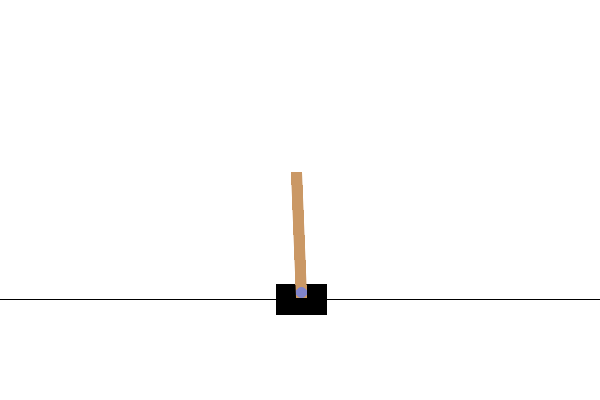

In [8]:
shots = record_episode(lambda observation: int(best_model.predict(observation, deterministic=True)[0]), seed=0)
print("続いた回数:", shots[-1][0])
imageio.v3.imwrite(FIGURES / "ch07_dqn.gif", [frame for _, frame in shots], duration=100, loop=0)
print("GIF の枚数:", len(shots))
Image(filename=FIGURES / "ch07_dqn.gif")

**期待する結果**（上の出力の読み方）: 一番よい時点のモデルは、`seed=0` で始めたこのエピソードで、上限の 500 回まで棒を立て続けました。GIF には、最初の絵と 5 ステップごとの絵 100 枚の、合わせて 101 枚を書き込みます。1 枚を 100 ミリ秒で表示します。5 ステップは CartPole の中の 0.1 秒なので、ほぼ実際の速さです。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、4-3節の GIF です。台車は真ん中から右へ寄っていき、そのあとは右寄りの位置で、棒をほぼまっすぐに立て続けます。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じエピソードのコマ送りの図を作ります。

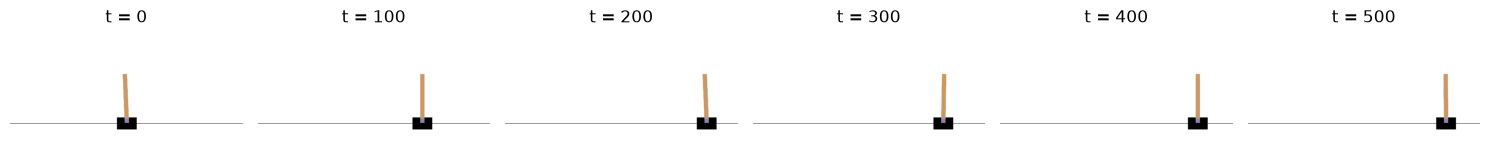

In [9]:
picks = np.linspace(0, len(shots) - 1, 6).round().astype(int)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.4))
for ax, i in zip(axes, picks):
    t, frame = shots[i]
    ax.imshow(frame[60:350, :])
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch07_dqn_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4-3節のエピソードから、等間隔に選んだ 6 枚（t = 0、100、200、300、400、500）です。t = 0 で真ん中にいた台車は、t = 100 には右へ寄っていて、そのあとは右寄りの位置のまま、棒をほぼまっすぐに立てています。

### 4-4. 学習曲線を見る

3節の表の Q学習と、4節の DQN の学習中の報酬の合計を、横軸を「それまでに進めたステップ数」（対数の目盛り）にして並べます。DQN については、2,500 ステップごとの評価の平均も点で描きます。

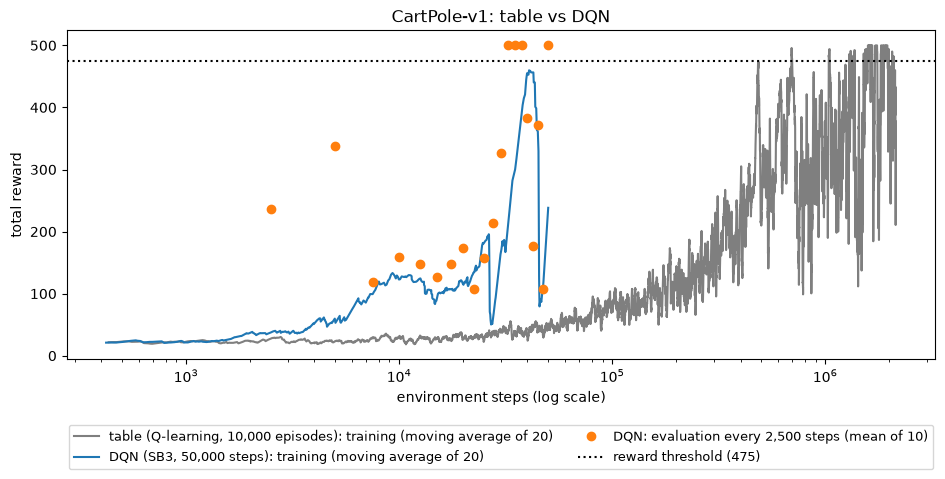

In [10]:
dqn_rewards = np.array(train_env.get_episode_rewards())
fig, ax = plt.subplots(figsize=(10, 5))
window = 20
for rewards, label, color in [(tabular_rewards, "table (Q-learning, 10,000 episodes)", "tab:gray"),
                              (dqn_rewards, "DQN (SB3, 50,000 steps)", "tab:blue")]:
    steps = np.cumsum(rewards)  # 各エピソードが終わった時点までのステップ数の合計
    moving = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax.plot(steps[window - 1:], moving, color=color, label=f"{label}: training (moving average of {window})")
ax.plot(eval_callback.evaluations_timesteps, np.mean(eval_callback.evaluations_results, axis=1), "o",
        color="tab:orange", label="DQN: evaluation every 2,500 steps (mean of 10)")
ax.axhline(475, color="black", linestyle=":", label="reward threshold (475)")
ax.set_xscale("log")
ax.set_xlabel("environment steps (log scale)")
ax.set_ylabel("total reward")
ax.set_title("CartPole-v1: table vs DQN")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "ch07_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 灰色の線が3節の表の Q学習、青い線が4節の DQN の、学習中の報酬の合計（直前 20 回の平均）です。橙の点が DQN の 2,500 ステップごとの評価（10 回の平均）、黒い点線が「解けた」の目安の 475 です。横軸は対数の目盛りで、1目盛りごとにステップ数が 10 倍になります。

灰色の線は、10 万ステップ（10⁵）のあたりまでは 100 に届かず、上がっていくのはそこから先で、200 万ステップ近くまで上下を繰り返しています。橙の点は、2,500 ステップで 236.1、5,000 ステップで 337.7 のあと、7,500〜25,000 ステップでは 107.8〜174.1 に下がりました。27,500 ステップで 214.5、30,000 ステップで 326.6 と上がり、32,500〜37,500 ステップで 500.0 になりました。そのあと、40,000〜47,500 ステップでは 107.8〜382.5 に下がり、最後の 50,000 ステップで再び 500.0 です。一番よい時点のモデルとして保存されたのは、最初に 500.0 になった 32,500 ステップの時点です（`EvalCallback` は、それまでの一番よい平均を上回ったときだけ保存します）。

学習中の報酬には、でたらめに選んだ行動の分も含まれます（第3章の4-4節）。DQN の ε は、RL Zoo の値（`exploration_fraction=0.16`、`exploration_final_eps=0.04`）により、学習の最初の 16%（8,000 ステップ）で 1.0 から 0.04 まで下がり、そのあとは 0.04 のままです。

4節の学習では、第1章と同じく `tensorboard_log="logs"` を指定したので、学習の記録が `logs` フォルダに書き出されています。TensorBoard で見る手順は、[第1章](../ch01_first_training/ch01_first_training.ipynb)の6-2節と同じです（フォルダを `chapters\ch07_cartpole_dqn\logs` にします）。著者が記録を読んで、`logs` フォルダの中の `dqn_cartpole_1` フォルダに、`rollout/ep_rew_mean`（直近のエピソードの報酬の平均）、`rollout/exploration_rate`（ε）、`eval/mean_reward`（`EvalCallback` の評価の平均）などの項目があることを確かめました。

## 5. 読む(1)：Q ネットワーク

4節のモデルの中で、Q 表の代わりをしているネットワーク（`q_net`）を見ます。

In [11]:
print(best_model.q_net)
n_params = sum(p.numel() for p in best_model.q_net.parameters())
print(f"ネットワークの重みの個数: {n_params:,}")
# 4-3節と同じ始まり方（seed=0）で5歩進め、各時点の観測と Q 値と、選んだ行動を表示する
play_env = gym.make("CartPole-v1")
observation, info = play_env.reset(seed=0)
for t in range(5):
    with torch.no_grad():
        q_values = best_model.q_net(torch.as_tensor(observation).unsqueeze(0))[0].numpy()
    action = int(q_values.argmax())
    print(f"t = {t}: 観測 {np.round(observation, 3)} → 左へ押す {q_values[0]:6.2f}、右へ押す {q_values[1]:6.2f} → {['左', '右'][action]}")
    observation, reward, terminated, truncated, info = play_env.step(action)

QNetwork(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (q_net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)
ネットワークの重みの個数: 67,586
t = 0: 観測 [ 0.014 -0.023 -0.046 -0.048] → 左へ押す  78.35、右へ押す  77.82 → 左
t = 1: 観測 [ 0.013 -0.217 -0.047  0.23 ] → 左へ押す  78.48、右へ押す  77.93 → 左
t = 2: 観測 [ 0.009 -0.412 -0.042  0.507] → 左へ押す  78.61、右へ押す  78.05 → 左
t = 3: 観測 [ 0.001 -0.606 -0.032  0.786] → 左へ押す  78.72、右へ押す  78.17 → 左
t = 4: 観測 [-0.011 -0.801 -0.016  1.069] → 左へ押す  78.94、右へ押す  78.40 → 左


**期待する結果**（上の出力の読み方）: Q ネットワークは、4 → 256 → 256 → 2 と、3つの全結合層（`Linear`）を `ReLU` でつないだ形です（`net_arch=[256, 256]` の指定どおり）。最初の `FlattenExtractor` は、観測を1列に並べる部分です。重みの個数（バイアスを含む）は 67,586 個で、3節の Q 表のマスの数（1,296）より多くなっています。

4-3節と同じ始まり方で5歩進めると、t = 0 の観測では、棒の角度（3つ目の値）が -0.046 で、少し左に傾いています。左へ押す Q 値が 78.35、右へ押すが 77.82 なので、左へ押しました。t = 1〜4 も左へ押していて、棒の角度は -0.047 から -0.016 へと 0 に近づき、棒の角速度（4つ目の値）は 0.23 から 1.069 へ大きくなっています。Q 値はどの時点も 77.8〜78.9 で、2つの行動の差は 0.5 ほどです。

Q 表は、状態の番号を渡すと、その行に並んだ行動ごとの Q 値を返す表でした。Q ネットワークは、観測の4つの数を渡すと、計算して、行動ごとの Q 値を返します。3節の区切った表のように、区画ごとにマスを用意するのではなく、重みで決まる1つの計算で、どんな観測の Q 値でも出せます。学習で動かすのは、表のマスの値ではなく、ネットワークの重みです（6-1節）。

## 6. 読む(2)：PyTorch の DQN のサンプル

SB3 の `DQN` と同じ仕組み（経験再生とターゲットネットワーク）を、PyTorch で短く書いたサンプルを動かして、読みます。設定は SB3 の RL Zoo の値とは違い、著者が決めた素直な値です（ネットワークは 128 × 128、学習率 0.001、1 ステップごとに 64 個の経験で学習、ターゲットネットワークの更新は 500 ステップごと、ε は最初の 10,000 ステップで 1.0 から 0.05 に減らす）。4節と同じく、2,500 ステップごとの評価で一番よい時点のネットワークを残します。著者の環境では 80 秒ほどかかりました。

In [12]:
# Q 表の代わりに使うニューラルネットワーク（観測4つ → 2つの行動の Q 値）
def make_q_net():
    return nn.Sequential(nn.Linear(4, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 2))


# ネットワーク net で、Q 値が大きいほうの行動を選ぶ方策（観測 → 行動の番号）を返す
def greedy_policy(net):
    def policy(observation):
        with torch.no_grad():
            return int(net(torch.as_tensor(observation)).argmax())
    return policy


# DQN で total_steps ステップ学習させる。replay=False で経験再生を、target=False でターゲットネットワークを外す
# 学習の Q ネットワークと、2,500 ステップごとの評価で一番よかった時点の Q ネットワークと、エピソードごとの報酬の合計を返す
def dqn(total_steps=50_000, replay=True, target=True, buffer_size=50_000, batch_size=64, lr=1e-3, gamma=0.99,
        learning_starts=1000, target_sync=500, epsilon_start=1.0, epsilon_end=0.05, epsilon_steps=10_000, seed=0):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    env = gym.make("CartPole-v1")
    q_net = make_q_net()
    target_net = make_q_net()
    target_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=lr)
    # 経験の貯め場所（リプレイバッファ）: 観測・行動・報酬・次の観測・終わったか を buffer_size 個まで貯める
    observations = np.zeros((buffer_size, 4), dtype=np.float32)
    actions = np.zeros(buffer_size, dtype=np.int64)
    rewards = np.zeros(buffer_size, dtype=np.float32)
    next_observations = np.zeros((buffer_size, 4), dtype=np.float32)
    dones = np.zeros(buffer_size, dtype=np.float32)
    stored = 0
    best_net, best_score = copy.deepcopy(q_net), -1.0
    episode_rewards, total = [], 0.0
    observation, info = env.reset(seed=seed)
    for step in range(total_steps):
        # 1. ε-greedy で行動を選び、1歩進めて、経験を貯める
        epsilon = max(epsilon_end, epsilon_start + (epsilon_end - epsilon_start) * step / epsilon_steps)
        if rng.random() < epsilon:
            action = int(rng.integers(2))
        else:
            action = greedy_policy(q_net)(observation)
        next_observation, reward, terminated, truncated, info = env.step(action)
        i = stored % buffer_size
        observations[i], actions[i], rewards[i] = observation, action, reward
        next_observations[i], dones[i] = next_observation, float(terminated)
        stored += 1
        total += reward
        observation = next_observation
        if terminated or truncated:
            episode_rewards.append(total)
            total = 0.0
            observation, info = env.reset()
        if step < learning_starts:
            continue
        # 2. 貯めた経験からでたらめに batch_size 個を選ぶ（経験再生を外すと、今の1歩の経験だけを使う）
        if replay:
            idx = rng.integers(min(stored, buffer_size), size=batch_size)
        else:
            idx = np.array([i])
        o, a, r, o2, d = (torch.as_tensor(x[idx]) for x in (observations, actions, rewards, next_observations, dones))
        # 3. 目標 = 報酬 + γ × 次の観測での最大の Q 値（ターゲットネットワークで計算する。外すと、学習中のネットワークで計算する）
        with torch.no_grad():
            next_q = (target_net if target else q_net)(o2).max(dim=1).values
            y = r + gamma * (1 - d) * next_q
        # 4. 選んだ行動の Q 値を目標に近づけるように、ネットワークの重みを少し動かす
        q = q_net(o).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = nn.functional.smooth_l1_loss(q, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 5. target_sync ステップごとに、ターゲットネットワークを学習中のネットワークの写しに更新する
        if target and step % target_sync == 0:
            target_net.load_state_dict(q_net.state_dict())
        # 2,500 ステップごとに 10 回遊ばせて評価し、一番よい時点のネットワークを残す
        if (step + 1) % 2500 == 0:
            score, _ = evaluate(greedy_policy(q_net), episodes=10, seed=200 + step)
            if score > best_score:
                best_net, best_score = copy.deepcopy(q_net), score
    return q_net, best_net, episode_rewards


start = time.perf_counter()
q_net, best_net, pt_rewards = dqn()
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
for name, net in [("最後の時点", q_net), ("一番よい時点", best_net)]:
    mean, std = evaluate(greedy_policy(net))
    print(f"{name}のネットワーク: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

学習にかかった時間: 81 秒


最後の時点のネットワーク: 報酬の合計の平均 158.2、標準偏差 3.4


一番よい時点のネットワーク: 報酬の合計の平均 495.4、標準偏差 23.1


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 81 秒でした。最後の時点（50,000 ステップ）のネットワークは平均 158.2、一番よい時点のネットワークは平均 495.4（標準偏差 23.1）です。

著者が学習の seed を 0〜4 に変えて測ったところ、一番よい時点のネットワークの平均は 436.3〜500.0（5 つのうち 3 つが 500.0）、最後の時点のネットワークは 89.9〜500.0 でした。

### 6-1. Q 表との違い：ネットワークの重みを少し動かす

```python
with torch.no_grad():
    next_q = (target_net if target else q_net)(o2).max(dim=1).values
    y = r + gamma * (1 - d) * next_q
q = q_net(o).gather(1, a.unsqueeze(1)).squeeze(1)
loss = nn.functional.smooth_l1_loss(q, y)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

目標 `y` は、第3章の Q学習と同じ「報酬 + γ × 次の観測での最大の Q 値」です。`(1 - d)` は、棒が倒れて終わった（`terminated`）経験では、次の観測の Q 値を足さないための掛け算です。第3章の Q学習では、表の1つのマスを、目標に α だけ近づけました。DQN では、選んだ行動の Q 値 `q` と目標 `y` のずれ（`loss`）を計算し、`loss.backward()` で、ずれを小さくする向きを重みごとに求め、`optimizer.step()` で重みを少し動かします。1つのマスだけでなく、ネットワーク全体の重みが動くので、ほかの観測の Q 値も一緒に変わります。

`torch.no_grad()` の中では、重みを動かす向き（勾配）を求めるための記録をしません。目標 `y` は近づける先で、動かす対象ではないので、この中で計算します。`smooth_l1_loss` は、ずれが小さいときはずれの2乗に比例し、大きいときはずれそのものに比例する損失（Huber 損失）です。

### 6-2. 経験再生

```python
observations[i], actions[i], rewards[i] = observation, action, reward
next_observations[i], dones[i] = next_observation, float(terminated)
...
idx = rng.integers(min(stored, buffer_size), size=batch_size)
```

1歩進めるたびに、その経験（観測・行動・報酬・次の観測・終わったか）を、リプレイバッファと呼ぶ配列に貯めます。学習では、貯めた経験の中からでたらめに 64 個を選び、まとめて重みを動かします。これが **経験再生** です。同じ経験を何度も使えることと、続けて起きた（よく似た）経験ばかりで重みを動かさずに済むことが、狙いとして知られています。

### 6-3. ターゲットネットワーク

```python
if target and step % target_sync == 0:
    target_net.load_state_dict(q_net.state_dict())
```

目標 `y` の計算には、学習中の `q_net` ではなく、その写しの `target_net` を使います。写しは 500 ステップごとにしか更新しないので、その間、目標の計算に使うネットワークは変わりません。これが **ターゲットネットワーク** です。学習中のネットワークで目標を計算すると、重みを動かすたびに目標まで動いてしまうので、それを避けるための工夫として知られています。

2つの工夫を外すと何が起きるかを、7節で確かめます。

## 7. 比べる：工夫を外す

6節のサンプルで、経験再生を外した設定（`replay=False`。今の1歩の経験だけで重みを動かす）と、ターゲットネットワークを外した設定（`target=False`。目標も学習中のネットワークで計算する）を学習させ、6節の設定と比べます。著者の環境では、このセル全体で 150 秒ほどかかりました。

no replay: 学習にかかった時間 70 秒


no target: 学習にかかった時間 73 秒
設定        一番よい時点の平均   最後の時点の Q 値（評価の最初の観測で、左・右）


full              495.4                 67.5         67.73


no replay         152.1                137.7         153.1
no target           9.5            1.341e+09     1.952e+09


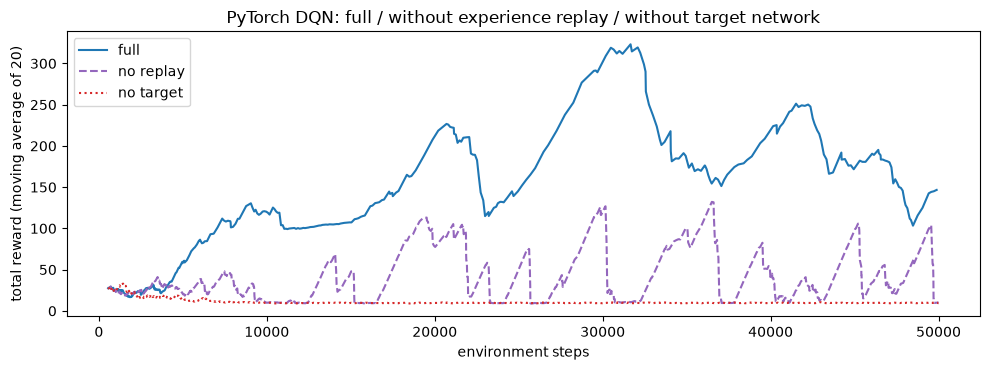

In [13]:
results = {"full": (q_net, best_net, pt_rewards)}
for name, kwargs in [("no replay", dict(replay=False)), ("no target", dict(target=False))]:
    start = time.perf_counter()
    results[name] = dqn(**kwargs)
    print(f"{name}: 学習にかかった時間 {time.perf_counter() - start:.0f} 秒")

start_obs, _ = gym.make("CartPole-v1").reset(seed=100)
print("設定        一番よい時点の平均   最後の時点の Q 値（評価の最初の観測で、左・右）")
for name, (last, best, _) in results.items():
    mean, _ = evaluate(greedy_policy(best))
    with torch.no_grad():
        q_values = last(torch.as_tensor(start_obs)).numpy()
    print(f"{name:10s} {mean:12.1f}         {q_values[0]:12.4g}  {q_values[1]:12.4g}")

fig, ax = plt.subplots(figsize=(10, 3.8))
styles = {"full": ("tab:blue", "-"), "no replay": ("tab:purple", "--"), "no target": ("tab:red", ":")}
for name, (_, _, rewards) in results.items():
    rewards = np.array(rewards)
    moving = np.convolve(rewards, np.ones(window) / window, mode="valid")
    color, linestyle = styles[name]
    ax.plot(np.cumsum(rewards)[window - 1:], moving, color=color, linestyle=linestyle, label=name)
ax.set_xlabel("environment steps")
ax.set_ylabel(f"total reward (moving average of {window})")
ax.set_title("PyTorch DQN: full / without experience replay / without target network")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "ch07_compare.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 経験再生を外した設定（`no replay`）の学習は 70 秒、ターゲットネットワークを外した設定（`no target`）は 73 秒でした。表の3行は、6節の2つの工夫を使った設定（`full`）と、外した2つの設定の結果です。

- 一番よい時点のネットワークの平均は、`full` が 495.4、`no replay` が 152.1、`no target` が 9.5 です
- 最後の時点のネットワークの Q 値（評価の最初の観測での、左へ押す・右へ押す）は、`full` が 67.5 と 67.73、`no replay` が 137.7 と 153.1、`no target` が約 13.4 億と約 19.5 億です（`1.341e+09` は 1.341 × 10⁹）

図は、学習中の報酬の合計（直前 20 回の平均）です。青い実線の `full` は、上下しながら 100〜320 あたりまで上がっています。紫の破線の `no replay` は、上がっては 10 前後に落ちることを繰り返していて、130 あたりより上には行っていません。赤い点線の `no target` は、学習の始めのうちに 10 前後まで下がり、そのあとはずっと 10 前後です。

著者が学習の seed を 0〜4 に変えて測ったところ、一番よい時点のネットワークの平均は、2つの工夫を使った設定が 436.3〜500.0、経験再生を外した設定が 133.3〜324.3、ターゲットネットワークを外した設定が 9.2〜9.5 でした。どの seed でも、この順に並びました。

ターゲットネットワークを外した設定の Q 値は、報酬が 1 ステップに 1 で γ が 0.99 の CartPole では、本来 100 を超えません（1 + 0.99 + 0.99² + … = 100）。上の出力の、ターゲットネットワークを外した設定の Q 値は、その上限を大きく超えています。目標を学習中のネットワークで計算したこの設定では、Q 値の見積もりが、本来ありえない大きさになっていました。経験再生を外した設定の Q 値（137.7・153.1）も、上限の 100 を超えています。著者が Q 値を確かめたのは、この seed 0 の1回です。

なお、`replay=False` の設定では、貯めた経験から選ばないことに加えて、1回に重みを動かすのに使う経験の数も、64 個から 1 個に減ります。6節の設定との成績の差には、この両方の違いが含まれます。

## 8. 遊んでみる

**やってみよう**:

- 3-3節の `BINS` を変えてみてください。著者が、学習の seed 0〜2 で 10,000 回学ばせて試したところ、`(3, 3, 6, 12)` は 448.3〜466.8、`(1, 1, 6, 12)` は 19.0〜500.0、`(6, 6, 12, 12)` は 313.9〜381.8 でした。区切り方で、成績も、seed によるばらつきも変わります
- 4-1節の `DQN(...)` の `seed` を変えてみてください。著者が 0〜4 で試したところ、一番よい時点のモデルはどれも 500.0、最後の時点のモデルは 121.0〜500.0 でした（4-2節）
- 4-1節の `ZOO_PARAMS` の値（たとえば `learning_rate` や `net_arch`）を変えたり、`model.learn` の `total_timesteps` を減らしたりして、学習曲線と成績がどう変わるかを見てみましょう
- 6節の `dqn()` の `target_sync`（ターゲットネットワークを更新する間隔）や `batch_size` を変えてみてください

## 9. まとめ

この章では、観測が連続した数の CartPole を、表とニューラルネットワークで解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 観測を区切って表に収め、Q学習で解く | `discretize()`、`tabular_q_learning()` | 3節 |
| SB3 の DQN を RL Zoo の値で学習させ、一番よい時点のモデルを残す | `DQN`、`EvalCallback` | 4節 |
| Q ネットワークの形と Q 値を見る | `model.q_net` | 5節 |
| PyTorch の DQN のサンプルを読む | `dqn()`、リプレイバッファ、`target_net` | 6節 |
| 経験再生とターゲットネットワークを外して比べる | `replay=False`、`target=False` | 7節 |

区切った表でも、seed によっては平均が 450 を超えましたが、百万を超えるステップの経験を使い、成績も seed によって大きく違いました。DQN は、Q 表をニューラルネットワークに置き換え、5 万ステップの学習で、上限の 500 回まで棒を立て続けるモデルを残せました。ただし、学習の途中で成績が上下するので、評価しながら一番よい時点を残しました。サンプルで外して比べると、経験再生を外した設定（1回に使う経験の数も 64 個から 1 個に減る）は成績が下がりました。ターゲットネットワークを外した設定は、成績がでたらめな方策（3-2節）より低くなり、Q 値の見積もりも本来の上限を大きく超えていました（Q 値は seed 0 で確かめました）。

DQN は、行動が「左か右か」のように数えられる環境で使う手法です。次の第8章では、同じ CartPole を、Q 値を経由せずに方策そのものを学ぶ方策勾配法（REINFORCE）で解く予定です。

- 次に読むもの: 第8章 CartPole の続き（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第8章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0・Stable-Baselines3 2.9.0 の動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。PyTorch のサンプルのコードは著者が書いたものです。

- V. Mnih et al., "Human-level control through deep reinforcement learning", *Nature*, 518, 529–533, 2015（DQN、経験再生、ターゲットネットワーク）
- Stable-Baselines3 Documentation, DQN: https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html
- Stable-Baselines3 Documentation, Callbacks（`EvalCallback`）: https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html
- RL Baselines3 Zoo, v2.9.0 の `hyperparams/dqn.yml`（CartPole-v1 のハイパーパラメータ）: https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/dqn.yml
- Farama Foundation, Gymnasium Documentation（CartPole の環境の説明）: https://gymnasium.farama.org/environments/classic_control/cart_pole/

4節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の CartPole の描画処理が出力したものです。グラフは、著者が matplotlib で描いたものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。